In [90]:
#imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.formula.api as smf

DOWNLOADS = Path.home() / "Downloads"
OUT_DIR = DOWNLOADS  

In [91]:
#load stress data
stress = pd.read_csv(DOWNLOADS / "stress_weeklies_aug2024jan2026.csv")
stress[["week_start", "week_end"]] = stress["date_range"].str.split(" to ", expand=True)
stress["week_start"] = pd.to_datetime(stress["week_start"])
stress["week_end"] = pd.to_datetime(stress["week_end"])

In [92]:
#load sleep data
sleep = pd.read_csv(DOWNLOADS / "sleepsd_weeklies_aug2024jan2026.csv")
sleep[["week_start", "week_end"]] = sleep["date_range"].str.split(" to ", expand=True)
sleep["week_start"] = pd.to_datetime(sleep["week_start"])
sleep["week_end"] = pd.to_datetime(sleep["week_end"])

In [93]:
#merge stress and sleep
stress_sleep = stress.merge(
    sleep[["name", "week_start", "week_end", "SD_bedtime_start"]],
    on=["name", "week_start", "week_end"],
    how="left"
)

In [94]:
#convert sleep SD to minutes
stress_sleep["SD_bedtime_start_td"] = pd.to_timedelta(stress_sleep["SD_bedtime_start"])
stress_sleep["SD_bedtime_start_min"] = stress_sleep["SD_bedtime_start_td"].dt.total_seconds() / 60

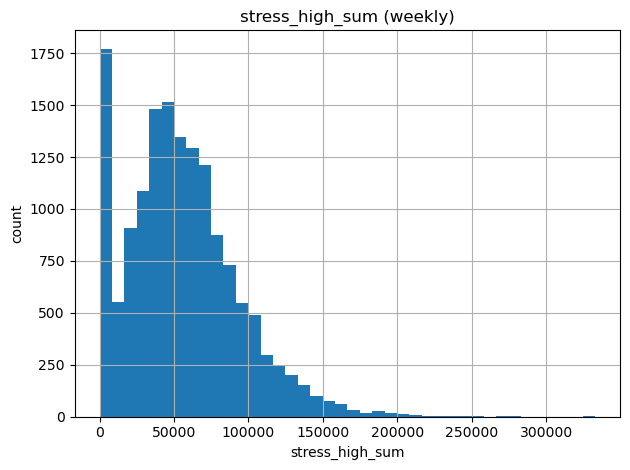

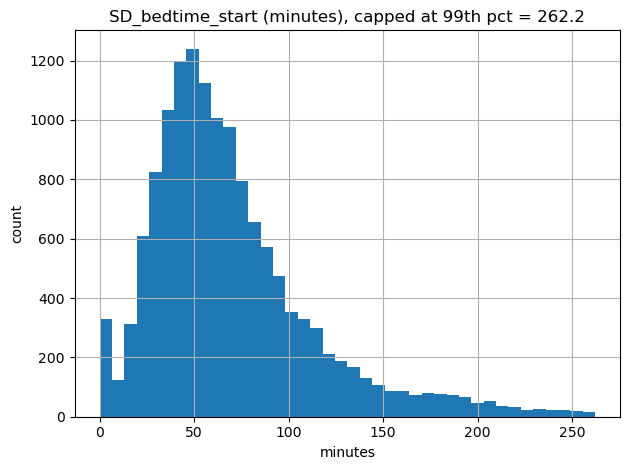

Sleep minutes cap (99th percentile): 262.21


In [95]:
#histograms
plt.figure()
stress_sleep["stress_high_sum"].dropna().hist(bins=40)
plt.title("stress_high_sum (weekly)")
plt.xlabel("stress_high_sum")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / "hist_stress_high_sum.png", dpi=200)
plt.show()

sleep_min = stress_sleep["SD_bedtime_start_min"].dropna()
x_cap = sleep_min.quantile(0.99)

plt.figure()
sleep_min.hist(bins=40, range=(0, x_cap))
plt.title(f"SD_bedtime_start (minutes), capped at 99th pct = {x_cap:.1f}")
plt.xlabel("minutes")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / "hist_SD_bedtime_start_min_capped.png", dpi=200)
plt.show()

print(f"Sleep minutes cap (99th percentile): {x_cap:.2f}")

In [96]:
#load and process cycle data
cycles_df = pd.read_csv(DOWNLOADS / "earlyfeb_finalweekliess.csv")
cycles = cycles_df[["id_num", "menzie_start", "cycle length (days)"]].copy()
cycles["menzie_start"] = pd.to_datetime(cycles["menzie_start"], errors="coerce")
cycles = cycles.dropna(subset=["menzie_start", "cycle length (days)"])
cycles["cycle_length_days"] = pd.to_numeric(cycles["cycle length (days)"], errors="coerce")
cycles = cycles.dropna(subset=["cycle_length_days"])
cycles = cycles.sort_values(["id_num", "menzie_start"])

/var/folders/jy/f2b3fc396cbgchccs456w30r0000gn/T/ipykernel_38377/1414682507.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  cycles_df = pd.read_csv(DOWNLOADS / "earlyfeb_finalweekliess.csv")


In [97]:
#calculate cycle regularity
cycle_reg = (
    cycles
    .groupby("id_num")["cycle_length_days"]
    .agg(
        mean_cycle_length="mean",
        sd_cycle_length="std",
        n_cycles="count"
    )
    .reset_index()
)
cycle_reg = cycle_reg[cycle_reg["n_cycles"] >= 3].copy()
print(f"Participants with 3+ cycles: {len(cycle_reg)}")

Participants with 3+ cycles: 240


In [98]:
# Descriptive statistics for cycle length
print(cycles["cycle_length_days"].describe())
print(f"\nTotal number of cycles: {len(cycles)}")
print(f"Number of unique participants: {cycles['id_num'].nunique()}")

count    2003.000000
mean       29.543684
std         8.271943
min        14.000000
25%        26.000000
50%        28.000000
75%        31.000000
max       177.000000
Name: cycle_length_days, dtype: float64

Total number of cycles: 2003
Number of unique participants: 302


In [99]:
#person-level stress
stress_person = (
    stress
    .groupby("name")["stress_high_sum"]
    .mean()
    .reset_index()
    .rename(columns={"name": "id_num", "stress_high_sum": "mean_total_stress_high"})
)
stress_person["id_num"] = pd.to_numeric(stress_person["id_num"], errors="coerce")


In [100]:
#load background data
background = pd.read_csv(DOWNLOADS / "backgrounddata.csv")
background["height"] = pd.to_numeric(background["height"], errors="coerce")
background["weight"] = pd.to_numeric(background["weight"], errors="coerce")
background["bmi"] = (background["weight"] / (background["height"]**2)) * 703

covars = background[["id_num", "years", "bmi"]].copy()
covars["id_num"] = pd.to_numeric(covars["id_num"], errors="coerce")
covars = covars.dropna(subset=["id_num"]).drop_duplicates(subset=["id_num"])


In [101]:
# Count unique id_num in each predictor file (stress, sleep, exercise)

# Stress file
stress_ids = pd.to_numeric(stress["name"], errors="coerce").dropna().nunique()
print(f"Stress file (stress_weeklies_aug2024nov2025.csv): {stress_ids} unique participants")

# Sleep file (merged into stress_sleep)
sleep_ids = pd.to_numeric(sleep["name"], errors="coerce").dropna().nunique()
print(f"Sleep file (sleepsd_weeklies_aug2024nov2025.csv): {sleep_ids} unique participants")

# Exercise file
exercise_ids = pd.to_numeric(exercise["name"], errors="coerce").dropna().nunique()
print(f"Exercise file (exercise_weeklies_aug2024nov2025.csv): {exercise_ids} unique participants")

# Also show how many have valid SD_bedtime_start_min after the merge
sleep_valid = stress_sleep.dropna(subset=["SD_bedtime_start_min"])
sleep_valid_ids = pd.to_numeric(sleep_valid["name"], errors="coerce").dropna().nunique()
print(f"\nParticipants with valid sleep SD (after merge): {sleep_valid_ids}")

# Background/covariates file
bg_ids = covars.dropna(subset=["id_num", "years", "bmi"])["id_num"].nunique()
print(f"Background file with valid age+BMI: {bg_ids} unique participants")

Stress file (stress_weeklies_aug2024nov2025.csv): 332 unique participants
Sleep file (sleepsd_weeklies_aug2024nov2025.csv): 330 unique participants
Exercise file (exercise_weeklies_aug2024nov2025.csv): 327 unique participants

Participants with valid sleep SD (after merge): 330
Background file with valid age+BMI: 276 unique participants


In [102]:
# merge for stress regression
df_reg = (
    cycle_reg
    .merge(stress_person, on="id_num", how="left")
    .merge(covars, on="id_num", how="left")
)
dfm = df_reg.dropna(subset=["sd_cycle_length", "mean_total_stress_high", "years", "bmi"]).copy()
print(f"Stress regression N: {len(dfm)}")

Stress regression N: 155


In [103]:
#z-score predictors
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

dfm["stress_z"] = zscore(dfm["mean_total_stress_high"])
dfm["age_z"] = zscore(dfm["years"])
dfm["bmi_z"] = zscore(dfm["bmi"])

In [104]:
#stress regression
model_stress = smf.ols("sd_cycle_length ~ stress_z + age_z + bmi_z", data=dfm).fit()
print(model_stress.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.4389
Date:                Tue, 24 Feb 2026   Prob (F-statistic):              0.725
Time:                        16:02:03   Log-Likelihood:                -490.98
No. Observations:                 155   AIC:                             990.0
Df Residuals:                     151   BIC:                             1002.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5531      0.468     11.874      0.0

In [105]:
#person-level sleep
sleep_person = (
    stress_sleep
    .groupby("name")["SD_bedtime_start_min"]
    .mean()
    .reset_index()
    .rename(columns={"name": "id_num", "SD_bedtime_start_min": "mean_sleepstart_sd_min"})
)
sleep_person["id_num"] = pd.to_numeric(sleep_person["id_num"], errors="coerce")


In [106]:
#merge for sleep regression
df_reg_sleep = (
    cycle_reg
    .merge(sleep_person, on="id_num", how="left")
    .merge(covars, on="id_num", how="left")
)
dfm_sleep = df_reg_sleep.dropna(subset=["sd_cycle_length", "mean_sleepstart_sd_min", "years", "bmi"]).copy()
print(f"Sleep regression N: {len(dfm_sleep)}")

dfm_sleep["sleep_z"] = zscore(dfm_sleep["mean_sleepstart_sd_min"])
dfm_sleep["age_z"] = zscore(dfm_sleep["years"])
dfm_sleep["bmi_z"] = zscore(dfm_sleep["bmi"])


Sleep regression N: 155


In [107]:
#sleep regression
model_sleep = smf.ols("sd_cycle_length ~ sleep_z + age_z + bmi_z", data=dfm_sleep).fit()
print(model_sleep.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                    0.3407
Date:                Tue, 24 Feb 2026   Prob (F-statistic):              0.796
Time:                        16:02:05   Log-Likelihood:                -491.13
No. Observations:                 155   AIC:                             990.3
Df Residuals:                     151   BIC:                             1002.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5531      0.468     11.862      0.0

In [108]:
#load exercise data
exercise = pd.read_csv(DOWNLOADS / "exercise_weeklies_aug2024nov2025.csv")
exercise["name"] = pd.to_numeric(exercise["name"], errors="coerce")

exercise_person = (
    exercise
    .groupby("name")["active_calories"]
    .agg(mean_active_calories="mean", n_weeks_ex="count")
    .reset_index()
    .rename(columns={"name": "id_num"})
)


In [109]:
#merge for exercise regression
df_reg_ex = (
    cycle_reg
    .merge(exercise_person, on="id_num", how="left")
    .merge(covars, on="id_num", how="left")
)
dfm_ex = df_reg_ex.dropna(subset=["sd_cycle_length", "mean_active_calories", "years", "bmi"]).copy()
print(f"Exercise regression N: {len(dfm_ex)}")

dfm_ex["exercise_z"] = zscore(dfm_ex["mean_active_calories"])
dfm_ex["age_z"] = zscore(dfm_ex["years"])
dfm_ex["bmi_z"] = zscore(dfm_ex["bmi"])

Exercise regression N: 155


In [110]:
#exercise regression
model_exercise = smf.ols("sd_cycle_length ~ exercise_z + age_z + bmi_z", data=dfm_ex).fit()
print(model_exercise.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.122
Date:                Tue, 24 Feb 2026   Prob (F-statistic):              0.342
Time:                        16:02:05   Log-Likelihood:                -489.94
No. Observations:                 155   AIC:                             987.9
Df Residuals:                     151   BIC:                             1000.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.5531      0.465     11.953      0.0

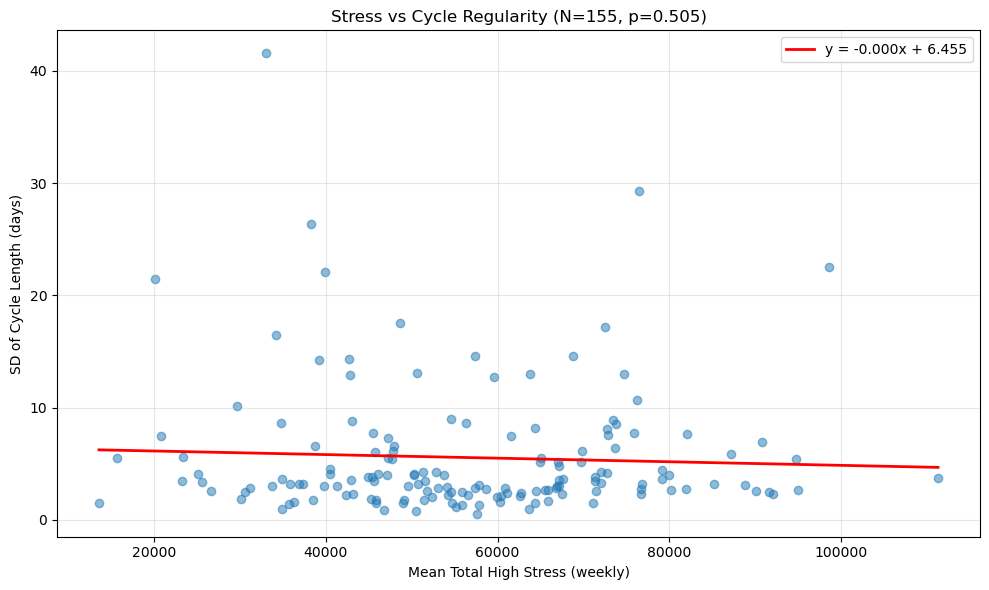

Correlation: -0.051


In [111]:
# Plotting block 1: Stress vs Cycle Regularity
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(dfm["mean_total_stress_high"], dfm["sd_cycle_length"], alpha=0.5)

# Add regression line
x_stress = dfm["mean_total_stress_high"]
y_stress = dfm["sd_cycle_length"]
z = np.polyfit(x_stress, y_stress, 1)
p = np.poly1d(z)
x_line = np.linspace(x_stress.min(), x_stress.max(), 100)
plt.plot(x_line, p(x_line), "r-", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

plt.xlabel("Mean Total High Stress (weekly)")
plt.ylabel("SD of Cycle Length (days)")
plt.title(f"Stress vs Cycle Regularity (N={len(dfm)}, p={model_stress.pvalues['stress_z']:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "regression_stress_vs_cycle.png", dpi=200)
plt.show()

print(f"Correlation: {x_stress.corr(y_stress):.3f}")

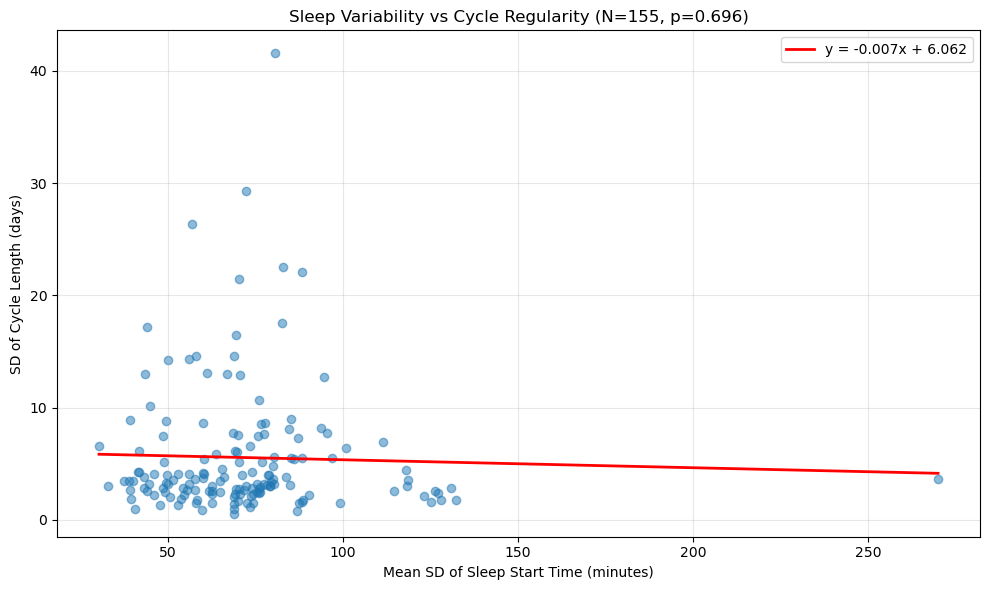

Correlation: -0.033


In [112]:
# Plotting block 2: Sleep Variability vs Cycle Regularity
plt.figure(figsize=(10, 6))
plt.scatter(dfm_sleep["mean_sleepstart_sd_min"], dfm_sleep["sd_cycle_length"], alpha=0.5)

# Add regression line
x_sleep = dfm_sleep["mean_sleepstart_sd_min"]
y_sleep = dfm_sleep["sd_cycle_length"]
z = np.polyfit(x_sleep, y_sleep, 1)
p = np.poly1d(z)
x_line = np.linspace(x_sleep.min(), x_sleep.max(), 100)
plt.plot(x_line, p(x_line), "r-", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

plt.xlabel("Mean SD of Sleep Start Time (minutes)")
plt.ylabel("SD of Cycle Length (days)")
plt.title(f"Sleep Variability vs Cycle Regularity (N={len(dfm_sleep)}, p={model_sleep.pvalues['sleep_z']:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "regression_sleep_vs_cycle.png", dpi=200)
plt.show()

print(f"Correlation: {x_sleep.corr(y_sleep):.3f}")

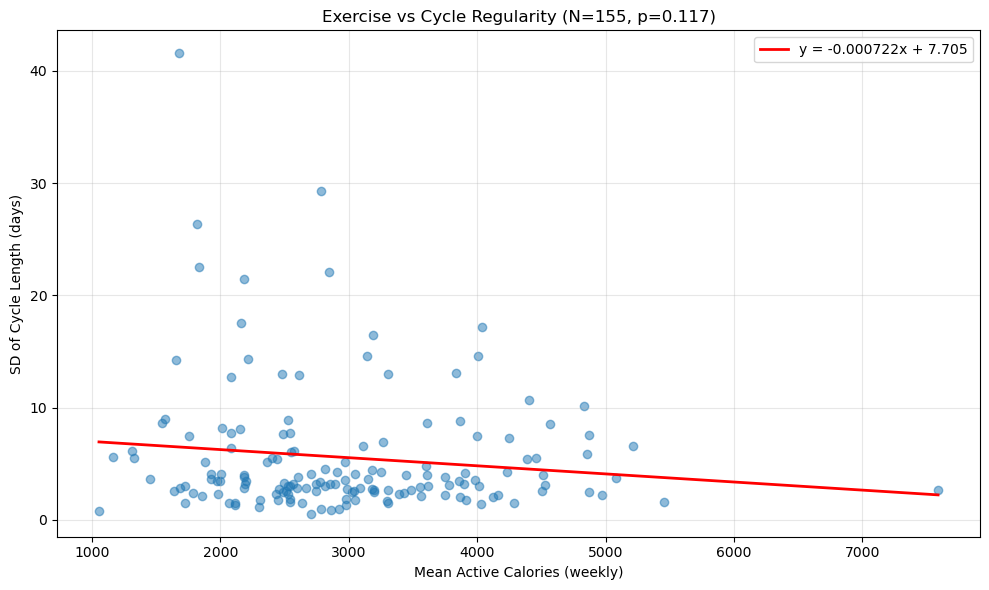

Correlation: -0.126


In [113]:
# Plotting block 3: Exercise vs Cycle Regularity
plt.figure(figsize=(10, 6))
plt.scatter(dfm_ex["mean_active_calories"], dfm_ex["sd_cycle_length"], alpha=0.5)

# Add regression line
x_exercise = dfm_ex["mean_active_calories"]
y_exercise = dfm_ex["sd_cycle_length"]
z = np.polyfit(x_exercise, y_exercise, 1)
p = np.poly1d(z)
x_line = np.linspace(x_exercise.min(), x_exercise.max(), 100)
plt.plot(x_line, p(x_line), "r-", linewidth=2, label=f'y = {z[0]:.6f}x + {z[1]:.3f}')

plt.xlabel("Mean Active Calories (weekly)")
plt.ylabel("SD of Cycle Length (days)")
plt.title(f"Exercise vs Cycle Regularity (N={len(dfm_ex)}, p={model_exercise.pvalues['exercise_z']:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "regression_exercise_vs_cycle.png", dpi=200)
plt.show()

print(f"Correlation: {x_exercise.corr(y_exercise):.3f}")

In [114]:
# COHORTS analysis
cohort_files = {
    "pill": "pill_weekliesaug2024-jan2026.csv",
    "perimenopause": "perimenopause_weekliesaug2024-jan2026.csv",
    "healthy_naturally_cycling": "healthy_nc_weekliesaug2024-jan2026.csv",
    "endometriosis": "endo_weekliesaug2024-jan2026.csv",
    "copper_iud": "copperIUD_weekliesaug2024-jan2026.csv",
    "hormonal_iud": "hormonalIUD_weekliesaug2024-jan2026.csv",
    "pcos": "pcsos_weekliesaug2024-jan2026.csv",
    "fibroids": "fibroids_weekliesaug2024-jan2026.csv",
}

# Load all cohort files and compute cycle regularity per cohort
cohort_data = {}  # raw cycle data per cohort
cohort_cycle_regs = {}  # cycle regularity (mean, sd, n) per cohort

for cohort_name, filepath in cohort_files.items():
    try:
        df = pd.read_csv(filepath, low_memory=False)
    except FileNotFoundError:
        print(f"WARNING: File not found for cohort '{cohort_name}': {filepath}")
        continue

    # Standardize columns
    temp = df[["id_num", "menzie_start", "cycle length (days)"]].copy()
    temp["menzie_start"] = pd.to_datetime(temp["menzie_start"], errors="coerce")
    temp["cycle_length_days"] = pd.to_numeric(temp["cycle length (days)"], errors="coerce")
    temp = temp.dropna(subset=["menzie_start", "cycle_length_days"])
    temp["id_num"] = pd.to_numeric(temp["id_num"], errors="coerce")
    temp = temp.dropna(subset=["id_num"])
    temp = temp.sort_values(["id_num", "menzie_start"])

    cohort_data[cohort_name] = temp

    # Calculate per-person cycle regularity
    reg = (
        temp
        .groupby("id_num")["cycle_length_days"]
        .agg(
            mean_cycle_length="mean",
            sd_cycle_length="std",
            n_cycles="count"
        )
        .reset_index()
    )
    reg = reg[reg["n_cycles"] >= 3].copy()
    cohort_cycle_regs[cohort_name] = reg

    print(f"Cohort '{cohort_name}': {len(temp)} cycles, "
          f"{temp['id_num'].nunique()} participants, "
          f"{len(reg)} with 3+ cycles")

Cohort 'pill': 230 cycles, 26 participants, 26 with 3+ cycles
Cohort 'perimenopause': 3 cycles, 1 participants, 1 with 3+ cycles
Cohort 'healthy_naturally_cycling': 724 cycles, 91 participants, 91 with 3+ cycles
Cohort 'endometriosis': 37 cycles, 5 participants, 5 with 3+ cycles
Cohort 'copper_iud': 54 cycles, 7 participants, 7 with 3+ cycles
Cohort 'hormonal_iud': 91 cycles, 11 participants, 11 with 3+ cycles
Cohort 'pcos': 95 cycles, 12 participants, 12 with 3+ cycles
Cohort 'fibroids': 104 cycles, 12 participants, 12 with 3+ cycles


In [115]:
# Descriptive statistics for "cycle length (days)" per cohort
for cohort_name, df in cohort_data.items():
    print("=" * 60)
    print(f"Cohort: {cohort_name}")
    print("-" * 60)
    print(df["cycle_length_days"].describe())
    print(f"Total cycles: {len(df)}")
    print(f"Unique participants: {df['id_num'].nunique()}")
    print()

Cohort: pill
------------------------------------------------------------
count    230.000000
mean      29.265217
std       10.689509
min        5.000000
25%       25.000000
50%       28.000000
75%       31.000000
max       80.000000
Name: cycle_length_days, dtype: float64
Total cycles: 230
Unique participants: 26

Cohort: perimenopause
------------------------------------------------------------
count     3.000000
mean     24.666667
std      16.563011
min       9.000000
25%      16.000000
50%      23.000000
75%      32.500000
max      42.000000
Name: cycle_length_days, dtype: float64
Total cycles: 3
Unique participants: 1

Cohort: healthy_naturally_cycling
------------------------------------------------------------
count    724.000000
mean      29.756906
std        9.825533
min        5.000000
25%       26.000000
50%       29.000000
75%       31.000000
max      115.000000
Name: cycle_length_days, dtype: float64
Total cycles: 724
Unique participants: 91

Cohort: endometriosis
--------

In [116]:
# Three regressions for each cohort
all_results = {}

for cohort_name, cycle_reg_df in cohort_cycle_regs.items():
    print("=" * 70)
    print(f"COHORT: {cohort_name.upper()}")
    print("=" * 70)

    results = {}

    # stress regression
    df_stress = (
        cycle_reg_df
        .merge(stress_person, on="id_num", how="left")
        .merge(covars, on="id_num", how="left")
    )
    dfm_stress = df_stress.dropna(
        subset=["sd_cycle_length", "mean_total_stress_high", "years", "bmi"]
    ).copy()

    if len(dfm_stress) >= 5:
        dfm_stress["stress_z"] = zscore(dfm_stress["mean_total_stress_high"])
        dfm_stress["age_z"] = zscore(dfm_stress["years"])
        dfm_stress["bmi_z"] = zscore(dfm_stress["bmi"])
        model_s = smf.ols("sd_cycle_length ~ stress_z + age_z + bmi_z",
                          data=dfm_stress).fit()
        results["stress"] = {
            "model": model_s, "data": dfm_stress, "n": len(dfm_stress)
        }
        print(f"\n--- Stress Regression (N={len(dfm_stress)}) ---")
        print(model_s.summary())
    else:
        print(f"\n--- Stress Regression: SKIPPED (N={len(dfm_stress)} < 10) ---")

    # sleep regression
    df_sleep = (
        cycle_reg_df
        .merge(sleep_person, on="id_num", how="left")
        .merge(covars, on="id_num", how="left")
    )
    dfm_sleep_c = df_sleep.dropna(
        subset=["sd_cycle_length", "mean_sleepstart_sd_min", "years", "bmi"]
    ).copy()

    if len(dfm_sleep_c) >= 5:
        dfm_sleep_c["sleep_z"] = zscore(dfm_sleep_c["mean_sleepstart_sd_min"])
        dfm_sleep_c["age_z"] = zscore(dfm_sleep_c["years"])
        dfm_sleep_c["bmi_z"] = zscore(dfm_sleep_c["bmi"])
        model_sl = smf.ols("sd_cycle_length ~ sleep_z + age_z + bmi_z",
                           data=dfm_sleep_c).fit()
        results["sleep"] = {
            "model": model_sl, "data": dfm_sleep_c, "n": len(dfm_sleep_c)
        }
        print(f"\n--- Sleep Regression (N={len(dfm_sleep_c)}) ---")
        print(model_sl.summary())
    else:
        print(f"\n--- Sleep Regression: SKIPPED (N={len(dfm_sleep_c)} < 10) ---")

    # exercise regression
    df_ex = (
        cycle_reg_df
        .merge(exercise_person, on="id_num", how="left")
        .merge(covars, on="id_num", how="left")
    )
    dfm_ex_c = df_ex.dropna(
        subset=["sd_cycle_length", "mean_active_calories", "years", "bmi"]
    ).copy()

    if len(dfm_ex_c) >= 5:
        dfm_ex_c["exercise_z"] = zscore(dfm_ex_c["mean_active_calories"])
        dfm_ex_c["age_z"] = zscore(dfm_ex_c["years"])
        dfm_ex_c["bmi_z"] = zscore(dfm_ex_c["bmi"])
        model_ex = smf.ols("sd_cycle_length ~ exercise_z + age_z + bmi_z",
                           data=dfm_ex_c).fit()
        results["exercise"] = {
            "model": model_ex, "data": dfm_ex_c, "n": len(dfm_ex_c)
        }
        print(f"\n--- Exercise Regression (N={len(dfm_ex_c)}) ---")
        print(model_ex.summary())
    else:
        print(f"\n--- Exercise Regression: SKIPPED (N={len(dfm_ex_c)} < 10) ---")

    all_results[cohort_name] = results
    print("\n")

COHORT: PILL

--- Stress Regression (N=26) ---
                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                 -0.063
Method:                 Least Squares   F-statistic:                    0.5066
Date:                Tue, 24 Feb 2026   Prob (F-statistic):              0.682
Time:                        16:02:07   Log-Likelihood:                -81.088
No. Observations:                  26   AIC:                             170.2
Df Residuals:                      22   BIC:                             175.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Inter

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/pytho

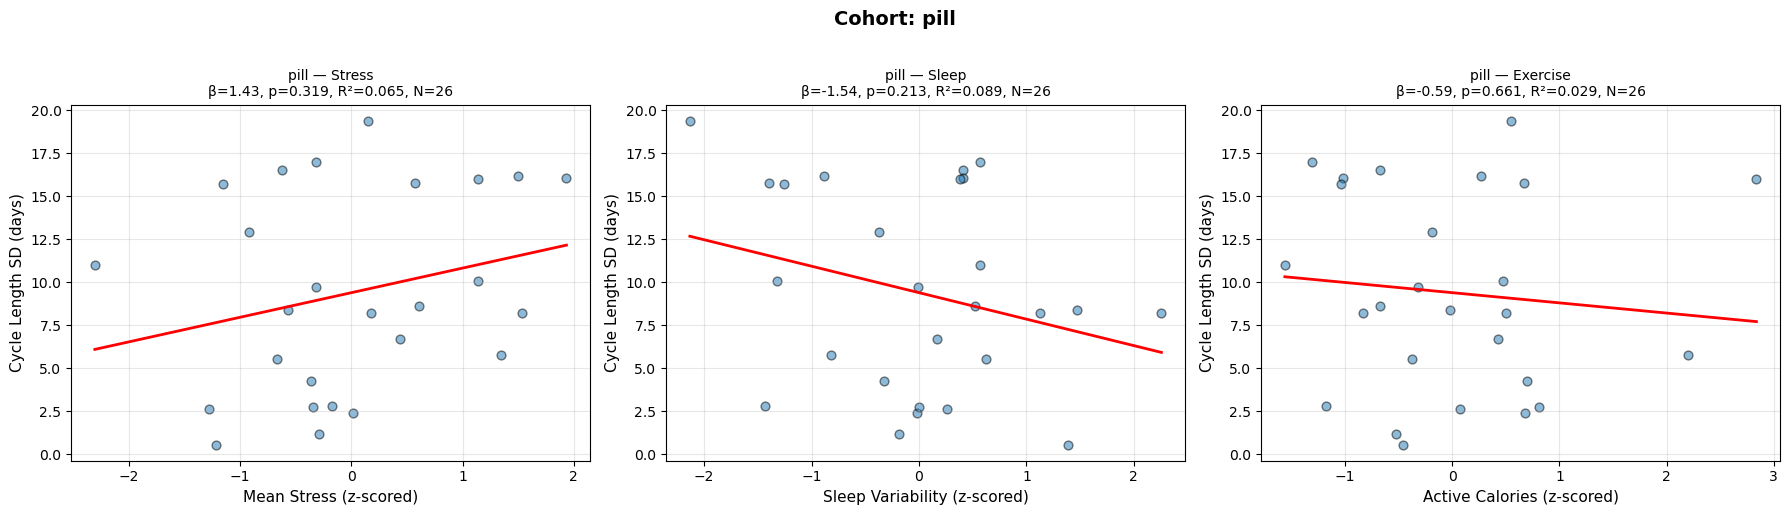

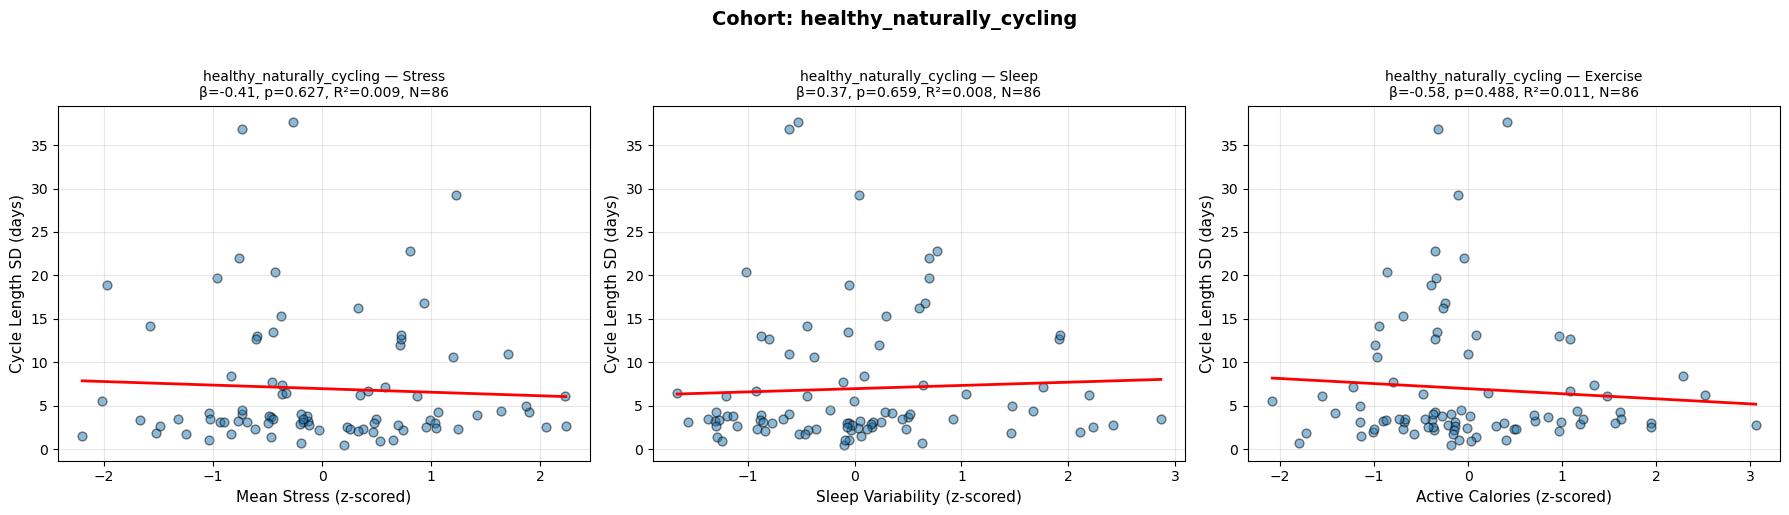

In [ ]:
# Plot the three regressions for each cohort
predictor_map = {
    "stress": ("stress_z", "Mean Stress (z-scored)"),
    "sleep": ("sleep_z", "Sleep Variability (z-scored)"),
    "exercise": ("exercise_z", "Active Calories (z-scored)"),
}

for cohort_name, results in all_results.items():
    n_models = len(results)
    if n_models == 0:
        continue

    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (reg_type, info) in zip(axes, results.items()):
        model = info["model"]
        data = info["data"]
        n = info["n"]
        x_col, x_label = predictor_map[reg_type]
        y_col = "sd_cycle_length"

        coef = model.params[x_col]
        pval = model.pvalues[x_col]
        r2 = model.rsquared

        ax.scatter(data[x_col], data[y_col], alpha=0.5, edgecolors="k", s=40)

        # Regression line (partial effect shown as simple line for visualization)
        import numpy as np
        x_range = np.linspace(data[x_col].min(), data[x_col].max(), 100)
        y_pred = model.params["Intercept"] + coef * x_range
        ax.plot(x_range, y_pred, color="red", linewidth=2)

        ax.set_xlabel(x_label, fontsize=11)
        ax.set_ylabel("Cycle Length SD (days)", fontsize=11)
        ax.set_title(
            f"{cohort_name} — {reg_type.capitalize()}\n"
            f"β={coef:.2f}, p={pval:.3f}, R²={r2:.3f}, N={n}",
            fontsize=10
        )
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Cohort: {cohort_name}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"regression_plots_{cohort_name}.png", dpi=200,
                bbox_inches="tight")
    plt.show()

In [ ]:
# Load person-level sleep average/SD data
sleepavg = pd.read_csv(DOWNLOADS / "sleepavg_aug2024jan2026.csv")
sleepavg = sleepavg.rename(columns={"name": "id_num"})
sleepavg["id_num"] = pd.to_numeric(sleepavg["id_num"], errors="coerce")

# Convert Average_Sleep and Sleep_StdDev from seconds to hours for interpretability
sleepavg["avg_sleep_hrs"] = sleepavg["Average_Sleep"] / 3600
sleepavg["sleep_sd_hrs"] = sleepavg["Sleep_StdDev"] / 3600

print(sleepavg[["avg_sleep_hrs", "sleep_sd_hrs"]].describe())
sleepavg.head()

In [54]:
# Merge cycle regularity with sleep avg/SD
cycle_sleep = cycle_reg.merge(sleepavg[["id_num", "avg_sleep_hrs", "sleep_sd_hrs"]],
                              on="id_num", how="inner")
print(f"Participants with cycle + sleep avg data: {len(cycle_sleep)}")
cycle_sleep.head()

Participants with cycle + sleep avg data: 160


,id_num,mean_cycle_length,sd_cycle_length,n_cycles,avg_sleep_hrs,sleep_sd_hrs
0,10200,24.052632,1.840099,19,7.986187,0.957694
1,10203,34.200000,17.164563,10,6.791715,1.139033
2,10205,32.200000,4.263541,10,7.669313,1.365781
3,10207,27.250000,5.545268,12,6.112047,1.789070
4,10208,28.615385,4.093459,13,8.258107,0.626608


In [55]:
# Regression: sd_cycle_length sleep_sd_hrs 
model_sleep_sd = smf.ols("sd_cycle_length ~ sleep_sd_hrs", data=cycle_sleep).fit()
print(model_sleep_sd.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8300
Date:                Mon, 16 Feb 2026   Prob (F-statistic):              0.364
Time:                        14:10:14   Log-Likelihood:                -506.00
No. Observations:                 160   AIC:                             1016.
Df Residuals:                     158   BIC:                             1022.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.0586      1.665      2.438   

In [56]:
# Regression: sd_cycle_length  avg_sleep_hrs
model_avg_sleep = smf.ols("sd_cycle_length ~ avg_sleep_hrs", data=cycle_sleep).fit()
print(model_avg_sleep.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                  0.004170
Date:                Mon, 16 Feb 2026   Prob (F-statistic):              0.949
Time:                        14:10:39   Log-Likelihood:                -506.41
No. Observations:                 160   AIC:                             1017.
Df Residuals:                     158   BIC:                             1023.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.1786      5.265      0.984

In [57]:
# Load weekly sleep-RHR regularity data 
sleeprhr = pd.read_csv(DOWNLOADS / "sleeprhr_weeklies_aug2024jan2026.csv")
sleeprhr[["week_start", "week_end"]] = sleeprhr["date_range"].str.split(" to ", expand=True)
sleeprhr["week_start"] = pd.to_datetime(sleeprhr["week_start"])
sleeprhr["week_end"] = pd.to_datetime(sleeprhr["week_end"])

# Person-level mean of within_four_hours_count
sleeprhr_person = (
    sleeprhr
    .groupby("name")["within_four_hours_count"]
    .mean()
    .reset_index()
    .rename(columns={"name": "id_num",
                      "within_four_hours_count": "mean_within_4hr_count"})
)
sleeprhr_person["id_num"] = pd.to_numeric(sleeprhr_person["id_num"], errors="coerce")

print(sleeprhr_person["mean_within_4hr_count"].describe())
sleeprhr_person.head()

count    84.000000
mean      2.399990
std       1.002588
min       0.000000
25%       1.682094
50%       2.239799
75%       2.973684
max       5.159091
Name: mean_within_4hr_count, dtype: float64


,id_num,mean_within_4hr_count
0,10199.0,2.590909
1,10201.0,1.685714
2,10202.0,0.781250
3,10203.0,3.418919
4,10204.0,2.054054


In [59]:
# Load daily sleep_hr data and compute person-level HRV SD 

sleep_hr = pd.read_csv(DOWNLOADS / "sleep_hr.csv", low_memory=False)

# If there is a 'name' or 'id_num' column, use it.  Otherwise uncomment and
# set the participant id manually or skip this block.
id_col = "name"

if id_col is not None:
    sleep_hr = sleep_hr.rename(columns={id_col: "id_num"})
    sleep_hr["id_num"] = pd.to_numeric(sleep_hr["id_num"], errors="coerce")
    sleep_hr["average_hrv"] = pd.to_numeric(sleep_hr["average_hrv"], errors="coerce")
    sleep_hr["average_heart_rate"] = pd.to_numeric(sleep_hr["average_heart_rate"], errors="coerce")
    sleep_hr["total_sleep_duration"] = pd.to_numeric(sleep_hr["total_sleep_duration"], errors="coerce")

    # Person-level: mean & SD of HRV, mean resting HR, mean sleep duration
    sleep_hr_person = (
        sleep_hr
        .groupby("id_num")
        .agg(
            mean_hrv=("average_hrv", "mean"),
            sd_hrv=("average_hrv", "std"),
            mean_rhr=("average_heart_rate", "mean"),
            mean_sleep_dur=("total_sleep_duration", "mean"),
            sd_sleep_dur=("total_sleep_duration", "std"),
        )
        .reset_index()
    )
    # Convert sleep duration from seconds to hours
    sleep_hr_person["mean_sleep_dur_hrs"] = sleep_hr_person["mean_sleep_dur"] / 3600
    sleep_hr_person["sd_sleep_dur_hrs"] = sleep_hr_person["sd_sleep_dur"] / 3600

    print(sleep_hr_person.describe())
else:
    print("⚠️  No participant ID column found in sleep_hr.csv. "
          "Available columns:", sleep_hr.columns.tolist())

             id_num    mean_hrv     sd_hrv   mean_rhr  mean_sleep_dur  \
count     81.000000   81.000000  81.000000  81.000000       81.000000   
mean   10367.061728   46.672275  12.470232  66.865629    25011.146637   
std      272.415737   22.577482   7.347950   7.837760     1697.290177   
min    10199.000000   16.553699   3.594558  45.868421    20604.920128   
25%    10223.000000   27.744780   6.669387  60.430726    23941.696113   
50%    10264.000000   41.400000  10.955680  66.939531    25192.071429   
75%    10290.000000   62.209150  15.459272  73.230030    26333.411765   
max    11014.000000  102.475325  45.948564  82.887500    29652.760736   

       sd_sleep_dur  mean_sleep_dur_hrs  sd_sleep_dur_hrs  
count     81.000000           81.000000         81.000000  
mean    4472.401498            6.947541          1.242334  
std     1090.018889            0.471469          0.302783  
min     2104.901699            5.723589          0.584695  
25%     3707.949806            6.650471   

In [89]:
import pandas as pd

# Assuming you already have a DataFrame called 'df'
# If not, replace this with your actual DataFrame creation code
# Example: df = pd.read_csv('your_file.csv')

# Strip whitespace from id_num and name columns
df['id_num'] = df['id_num'].astype(str).str.strip()
df['name'] = df['name'].str.strip()

# Display the first few rows to verify the changes
print(df[['id_num', 'name']].head())

KeyError: 'id_num'


## Explanation:

1. The `.str.strip()` method removes leading and trailing whitespace from string values
2. For `id_num`, I first convert to string type with `.astype(str)` in case it's stored as a numeric type
3. For `name`, which is likely already a string, we can directly apply `.str.strip()`

If you need to strip specific characters instead of whitespace, you can pass those characters as an argument to `.strip()`. For example: `.str.strip('_#')` would remove underscores and hash symbols from the beginning and end of strings.

## Useful Packages:

If you're doing more data cleaning, consider these Python packages:
- pandas: For data manipulation
- numpy: For numerical operations
- re: For more complex string operations using regular expressions
- cleanco: Specialized for cleaning company names
- ftfy: Fixes text encoding issues

In [60]:
# Merge cycle regularity with daily sleep HR metrics 
if id_col is not None:
    cycle_hr = cycle_reg.merge(sleep_hr_person, on="id_num", how="inner")
    print(f"Participants with cycle + sleep_hr data: {len(cycle_hr)}")
    display(cycle_hr.head())

Participants with cycle + sleep_hr data: 56


,id_num,mean_cycle_length,sd_cycle_length,n_cycles,mean_hrv,sd_hrv,mean_rhr,mean_sleep_dur,sd_sleep_dur,mean_sleep_dur_hrs,sd_sleep_dur_hrs
0,10199,29.250000,2.362908,4,41.400000,13.513602,71.612500,24049.000000,6918.092198,6.680278,1.921692
1,10203,34.200000,17.164563,10,68.616803,9.285716,57.141137,24635.901639,3301.981610,6.843306,0.917217
2,10204,30.818182,2.638870,11,44.562628,14.185560,71.890144,24527.618070,4538.964240,6.813227,1.260823
3,10205,32.200000,4.263541,10,86.208243,24.871584,55.199024,27275.726681,4055.009270,7.576591,1.126391
4,10207,27.250000,5.545268,12,29.235732,7.633490,60.776985,22236.774194,5045.288282,6.176882,1.401469


In [61]:
# Regression: sd_cycle_length  sd_hrv 
if id_col is not None and len(cycle_hr.dropna(subset=["sd_hrv", "sd_cycle_length"])) > 5:
    model_hrv = smf.ols("sd_cycle_length ~ sd_hrv", data=cycle_hr).fit()
    print(model_hrv.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                    0.1770
Date:                Mon, 16 Feb 2026   Prob (F-statistic):              0.676
Time:                        14:18:49   Log-Likelihood:                -183.87
No. Observations:                  56   AIC:                             371.7
Df Residuals:                      54   BIC:                             375.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.6856      1.733      3.858      0.0

In [62]:
# Regression: sd_cycle_length ~ mean_rhr 
if id_col is not None and len(cycle_hr.dropna(subset=["mean_rhr", "sd_cycle_length"])) > 5:
    model_mean_rhr = smf.ols("sd_cycle_length ~ mean_rhr", data=cycle_hr).fit()
    print(model_mean_rhr.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.946
Date:                Mon, 16 Feb 2026   Prob (F-statistic):              0.169
Time:                        14:18:54   Log-Likelihood:                -182.97
No. Observations:                  56   AIC:                             369.9
Df Residuals:                      54   BIC:                             374.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.9942      7.887      2.155      0.0

In [63]:
# Regression: sd_cycle_length  sd_sleep_dur_hrs 
if id_col is not None and len(cycle_hr.dropna(subset=["sd_sleep_dur_hrs", "sd_cycle_length"])) > 5:
    model_sleep_dur_sd = smf.ols("sd_cycle_length ~ sd_sleep_dur_hrs", data=cycle_hr).fit()
    print(model_sleep_dur_sd.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                  0.003121
Date:                Mon, 16 Feb 2026   Prob (F-statistic):              0.956
Time:                        14:19:01   Log-Likelihood:                -183.96
No. Observations:                  56   AIC:                             371.9
Df Residuals:                      54   BIC:                             376.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            6.2698      3.908  

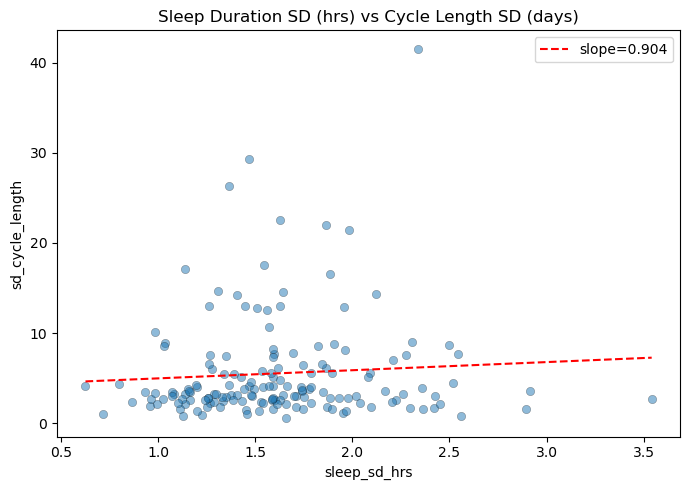

Saved: scatter_sleep_sd_hrs_vs_sd_cycle_length.png


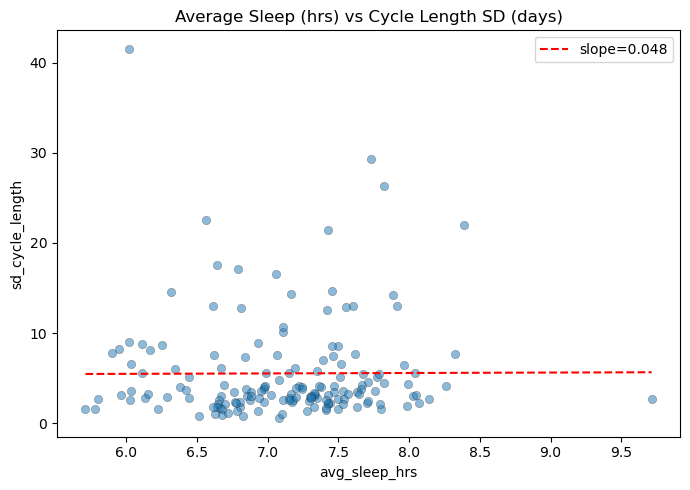

Saved: scatter_avg_sleep_hrs_vs_sd_cycle_length.png


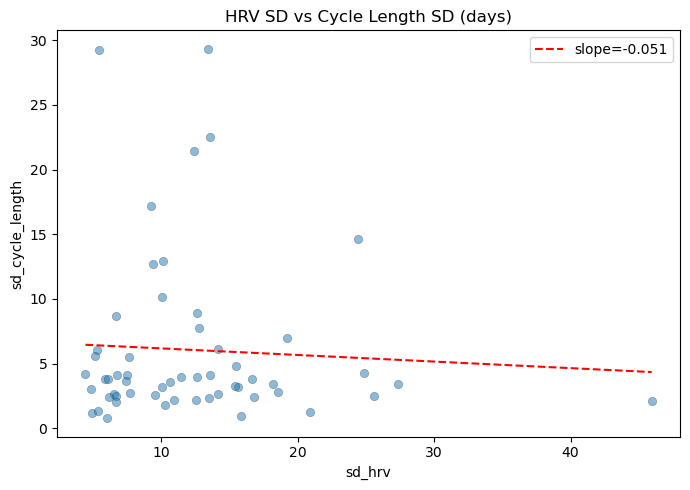

Saved: scatter_sd_hrv_vs_sd_cycle_length.png


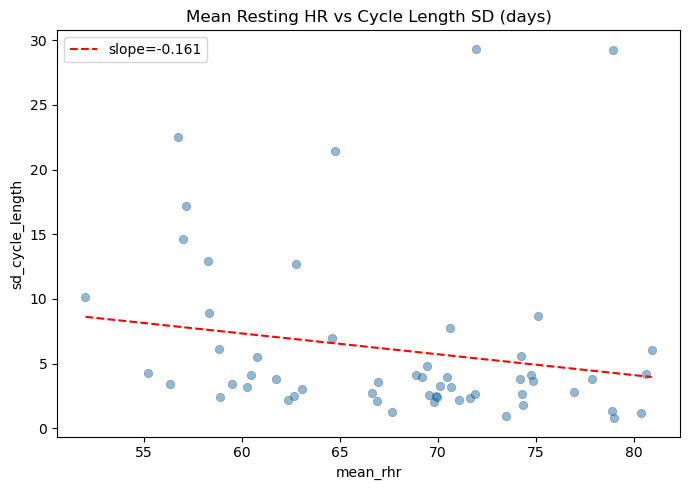

Saved: scatter_mean_rhr_vs_sd_cycle_length.png


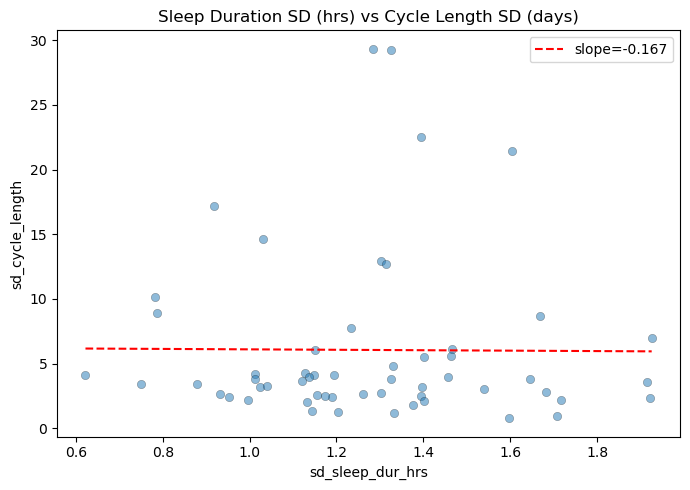

Saved: scatter_sd_sleep_dur_hrs_vs_sd_cycle_length.png


In [64]:

plot_specs = []

# From sleepavg
if "cycle_sleep" in dir() and len(cycle_sleep) > 0:
    plot_specs.append(("sleep_sd_hrs", "sd_cycle_length", cycle_sleep,
                       "Sleep Duration SD (hrs) vs Cycle Length SD (days)"))
    plot_specs.append(("avg_sleep_hrs", "sd_cycle_length", cycle_sleep,
                       "Average Sleep (hrs) vs Cycle Length SD (days)"))

# From sleeprhr
if "cycle_rhr" in dir() and len(cycle_rhr) > 0:
    plot_specs.append(("mean_within_4hr_count", "sd_cycle_length", cycle_rhr,
                       "Mean Within-4hr Count vs Cycle Length SD (days)"))

# From sleep_hr
if "cycle_hr" in dir() and len(cycle_hr) > 0:
    for xvar, title_prefix in [
        ("sd_hrv", "HRV SD"),
        ("mean_rhr", "Mean Resting HR"),
        ("sd_sleep_dur_hrs", "Sleep Duration SD (hrs)"),
    ]:
        subset = cycle_hr.dropna(subset=[xvar, "sd_cycle_length"])
        if len(subset) > 5:
            plot_specs.append((xvar, "sd_cycle_length", subset,
                               f"{title_prefix} vs Cycle Length SD (days)"))

for xvar, yvar, df, title in plot_specs:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[xvar], df[yvar], alpha=0.5, edgecolors="k", linewidth=0.3)
    # OLS trend line
    mask = df[[xvar, yvar]].dropna().index
    if len(mask) > 2:
        z = np.polyfit(df.loc[mask, xvar], df.loc[mask, yvar], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[xvar].min(), df[xvar].max(), 100)
        plt.plot(x_line, p(x_line), "r--", linewidth=1.5, label=f"slope={z[0]:.3f}")
        plt.legend()
    plt.xlabel(xvar)
    plt.ylabel(yvar)
    plt.title(title)
    plt.tight_layout()
    fname = f"scatter_{xvar}_vs_{yvar}.png".replace(" ", "_")
    plt.savefig(OUT_DIR / fname, dpi=200)
    plt.show()
    print(f"Saved: {fname}")

In [65]:

sleep_hr_raw = pd.read_csv(DOWNLOADS / "sleep_hr.csv", nrows=5, low_memory=False)
print("Columns in sleep_hr.csv:")
print(sleep_hr_raw.columns.tolist())
print(f"\nNumber of columns: {len(sleep_hr_raw.columns)}")
print("\nFirst 5 rows:")
display(sleep_hr_raw.head())
print("\nData types:")
print(sleep_hr_raw.dtypes)

Columns in sleep_hr.csv:
['day', 'type', 'total_sleep_duration', 'average_breath', 'average_heart_rate', 'average_hrv', 'awake_time', 'bedtime_end', 'bedtime_start', 'deep_sleep_duration', 'efficiency', 'heart_rate', 'hrv', 'latency', 'light_sleep_duration', 'low_battery_alert', 'lowest_heart_rate', 'movement_30_sec', 'period', 'readiness', 'readiness_score_delta', 'rem_sleep_duration', 'restless_periods', 'sleep_algorithm_version', 'sleep_analysis_reason', 'sleep_phase_30_sec', 'sleep_phase_5_min', 'sleep_score_delta', 'time_in_bed', 'id', 'participant_id', 'name', 'email', 'group', 'lowest_bpm', 'lowest_bpm_time', 'within_four_hours']

Number of columns: 37

First 5 rows:


,day,type,total_sleep_duration,average_breath,average_heart_rate,average_hrv,awake_time,bedtime_end,bedtime_start,deep_sleep_duration,...,sleep_score_delta,time_in_bed,id,participant_id,name,email,group,lowest_bpm,lowest_bpm_time,within_four_hours
0,2024-09-14,long_sleep,25110,16.875,67.000,49.0,2079,2024-09-14 16:10:38+00:00,2024-09-14 08:37:29+00:00,7530,...,0.0,27189,071a9875-48fa-4083-92a3-bd0c4b52cae7,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,62.0,2024-09-14 12:53:44+00:00,False
1,2024-09-15,long_sleep,33030,16.750,65.750,52.0,1825,2024-09-15 17:10:56+00:00,2024-09-15 07:30:01+00:00,7440,...,0.0,34855,2dde3d12-89f4-4816-86a0-29cab124362d,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,58.0,2024-09-15 10:09:17+00:00,True
2,2024-09-16,long_sleep,19500,17.625,66.625,39.0,2280,2024-09-16 14:10:29+00:00,2024-09-16 08:07:29+00:00,5730,...,0.0,21780,806ef357-b1ab-4cdb-8e40-d50dfc0a66db,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,62.0,2024-09-16 11:37:44+00:00,True
3,2024-09-17,long_sleep,14160,17.125,67.625,47.0,1888,2024-09-17 14:38:28+00:00,2024-09-17 10:11:00+00:00,3690,...,0.0,16048,d238dd7a-e004-4f34-91ce-5e9ad95777a9,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,61.0,2024-09-17 14:07:44+00:00,True
4,2024-09-18,long_sleep,21780,17.000,72.750,32.0,1750,2024-09-18 14:42:12+00:00,2024-09-18 08:10:02+00:00,5520,...,0.0,23530,7593aa1e-15d4-4982-bcdb-4a00f44696dd,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,63.0,2024-09-18 14:07:46+00:00,False



Data types:
day                         object
type                        object
total_sleep_duration         int64
average_breath             float64
average_heart_rate         float64
average_hrv                float64
awake_time                   int64
bedtime_end                 object
bedtime_start               object
deep_sleep_duration          int64
efficiency                   int64
heart_rate                  object
hrv                         object
latency                      int64
light_sleep_duration         int64
low_battery_alert             bool
lowest_heart_rate          float64
movement_30_sec             object
period                       int64
readiness                   object
readiness_score_delta      float64
rem_sleep_duration           int64
restless_periods             int64
sleep_algorithm_version     object
sleep_analysis_reason      float64
sleep_phase_30_sec          object
sleep_phase_5_min           object
sleep_score_delta          float64
time_in